In [1]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import colors

from scipy.integrate import quad, dblquad
from scipy.integrate import cumulative_trapezoid  # numerični podatki

np.set_printoptions(legacy='1.25')

In [2]:
def graf(v=5, s=5):
    '''
        Funkcija pripravi graf in nastavi koordinatne osi 
    '''
    fig, ax = plt.subplots(figsize=(s,v))
    ax.set_prop_cycle(color=colors.Texas)
    ax.set_xlabel('x', loc='right')
    ax.set_ylabel('y', loc='top')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False);
    ax.axis('equal') 
    return ax

# Numerično integriranje

## Neodvisni spremenljivki 

(Mencinger, 2011, str. 217) Izračunaj 
$$ \iint \limits_\Delta (x^3 + xy^2)dxdy$$
kjer je $\Delta = \{(x,y); 1\leq x\leq 2, 0 \leq y \leq 1\}$. 

Dvojni določeni integral ročno računamo kot dvakratni integral, kjer najprej izračunamo nedoločen integral po eni spremenljivki, vstavimo meje in dobimo funkcijo ene spremenljivke. Nato izračunamo še nedoločen integral po drugi spremenljivki ter vstavimo meje. Tega z numerično metodo ne moremo narediti, saj ne računamo nedoločenega integrala.

Dvojni integral tako ne bomo računali kot dvakratni z uporabo SciPy funkcije `quad()`, temveč s funkcijo za izračun dvojnega integrala `dblquad()`. Podobno bi izračunali tudi trojni ali večkratni integral, funkcije za računanje poiščemo v knjižnici SciPy.

Računanje dvojnega integrala zahteva opredelitev območja integriranja, kar pomeni, da moramo določiti meje za obe spremenljivki. Bodimo pozorni na to, da so v našem primeru meje integrala določene tako, da ne izražajo odvisnosti med spremenljivkama $x$ in $y$. Spremenljivki sta torej medsebojno neodvisni in njune meje lahko določimo kot numerične vrednosti, in sicer po $x$ integriramo v mejah od 1 do 2 ter po $y$ v mejah od 0 do 1.

Najprej definiramo integrand kot Python funkcijo.

In [79]:
def f(x, y):
    return (x**3 + x*y**2)

Funkcijo integriramo, tako da navedemo integrand ter meje ene in druge spremenljivke. Pri navajanju mej moramo paziti na vrstni red. Najprej navedemo meje za spremenljivko, ki smo jo pri definiciji funkcije navedli kot drugi parameter (torej $y$) in nato meje spremenljivke, ki predstavlja prvi parameter (torej $x$). Vrstni red navajanja meja sledi istemu principu, kot dvojni integral zapišemo v obliki dvakratnega:
$$\int \limits_0^1 dy \int \limits_1^2 (x^3 + xy^2)dx$$

In [67]:
I = dblquad(f, 0, 1, 1, 2)
I

(4.25, 5.82144645503e-14)

Če želimo, lahko seveda integriramo tudi v nasprotnem vrstnem redu, le da v tem primeru moramo zamenjati tudi vrstni red spremenljivk v funkciji $f$.

In [72]:
def f(y, x):
    return (x**3 + x*y**2)

I = dblquad(f, 1, 2, 0, 1)
I

(4.25, 9.592231585442713e-14)

Kot zanimivost poskusimo izračunati še dvojni integral z uporabo enojnega s funkcijo `quad()`. Po $x$ integriramo za vsak $y$ in dobimo povprečno vrednost integralov po $x$.

In [73]:
def f(x, y):
    return (x**3 + x*y**2)

I = 0
min_y = 0
max_y = 1
korakov = 100000
for y_i in np.linspace(min_y, max_y, korakov):
    I += quad(f, 1, 2, args=(y_i,))[0]

(max_y-min_y)*I/korakov

4.250002500025094

Integral predstavlja volumen telesa med modro in oranžno ploskivjo na sliki.

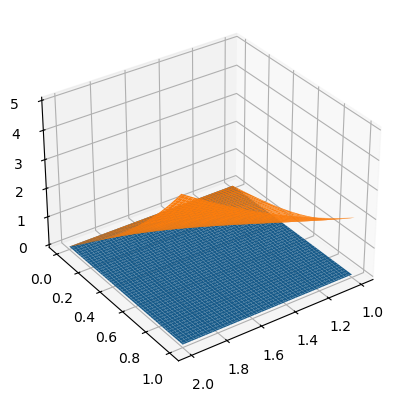

In [104]:
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
ax.view_init(32, 55)
x = np.linspace(1, 2, 100)
y = np.linspace(0, 1, 100)

x, y = np.meshgrid(x, y)

z = f(y, x)

ax.plot_surface(x, y, np.zeros(z.shape))
ax.plot_surface(x, y, z);

## Odvisni spremenljivki

Funkcijo dveh spremenljivk $f(x,y)$ lahko integriramo po območju, ki je definirano z medsebojno odvisnostjo spremenljivk $x$ in $y$.

(Mencinger, 2011, str. 217)Izračunaj integral
$$\iint \limits_\Delta e^{1-x-2y}dxdy$$
kjer je $\Delta$ definiran kot trikotnik, ki ga oklepajo premica $y = -x + 1$ in obe koordinatni osi.

Integrand zapišemo kot funkcijo. Ker bomo najprej integrirali po $y$ in nato po $x$, tako zapišemo tudi vrstni red parametrov.

In [74]:
def f(y, x):
    return np.exp(1-x-2*y)

Z integriranjem bomo izračunali volumen telesa pod ploskvijo, ki jo prikazuje nasledni graf.

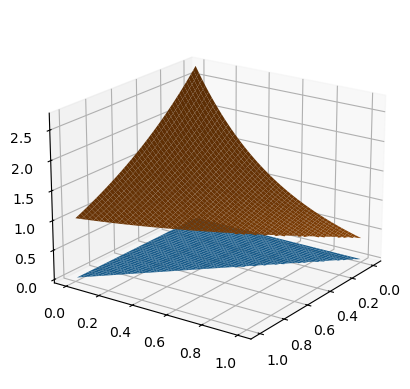

In [75]:
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
ax.view_init(20, 35)
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

x, y = np.meshgrid(x, y)

z = f(y, x)
maska = y <= (-x + 1)
z_ = np.where(maska, z, np.nan)  #odstranimo vrednosti izvem meja trikotnika
zeros_ = np.where(maska, np.zeros(z_.shape), np.nan)

ax.plot_surface(x, y, zeros_)
ax.plot_surface(x, y, z_);

Integral izračunamo s funkcijo `dblquad()`. Izziv te naloge je, da pravilno določimo meje. 

Kot je razvidno iz grafa funkcije $y = -x + 1$, vrednost $x$ integriramo v mejah $0 \leq x \leq 1$ in $y$ v mejah $0 \leq y \leq 1-x$. 

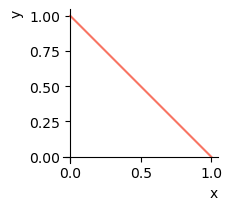

In [76]:
x = np.linspace(0,1,100)
y = -x + 1
ax = graf(2,2)
ax.plot(x, y);

Integral bi kot dvakratni integral zapisali kot

$$\int \limits_0^1 dx \int \limits_0^{1-x}e^{1-x-2y}dy$$

Iz zapisa vidimo, kako moramo definirati meje. Zgornjo mejo za $y$ bomo zapisali kot funkcijo spremenljivke $x$. Zato definiramo funkcijo `meja_max_y(x)`.

In [77]:
def meja_max_y(x):
    return 1-x

Izračunamo integral

In [78]:
I = dblquad(f, 0, 1, 0, meja_max_y)
I

(0.5430806348152437, 1.3010185015597338e-14)